# BbValidator: как это работает

Проход по пайплайну от координат до вердикта, на живых данных из `data/`.

Модель — дешёвый предфильтр дизайнируемости остова: заменяет дорогую проверку
(ProteinMPNN × 8 → ESMFold × 8) одним проходом по координатам. Рабочий скор —
**предсказанный scRMSD**, меньше значит дизайнируемее.

Разделы: фронтенд → проверка хиральности → энкодер и головы → батч → атрибуция признаков.

In [1]:
# Jupyter открывает тетрадь в notebooks/, а пути проекта относительны от корня.
import os
while not os.path.exists("inference.py") and os.getcwd() != os.path.dirname(os.getcwd()):
    os.chdir("..")
assert os.path.exists("inference.py"), "Откройте тетрадь внутри репозитория BbValidator"
print("Корень репозитория:", os.getcwd())

Корень репозитория: /home/pc/PycharmProjects/BbValidator


In [2]:
import glob
import torch

from inference import _autocast_ctx, build_model, center_coords, parse_pdb_to_backbone
from filter_designability import FAILURE_MODE_NAMES

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Устройство:", device)

# Продакшн-ранжировщик: совместное обучение (по-остаточный lDDT + глобальный scRMSD).
# per_residue=True включает голову, выдающую профиль по остаткам.
model = build_model("checkpoints/joint_model.pth", device, per_residue=True)

/home/pc/PycharmProjects/BbValidator/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Устройство: cuda
Загрузка весов из checkpoints/joint_model.pth...


## 1. Парсинг backbone

На вход идут только три атома остова на остаток: N, Cα, C. Никакой последовательности,
никаких боковых цепей — модель работает с чистой геометрией каркаса.

In [3]:
coords_np = center_coords(parse_pdb_to_backbone("data/2RJV.pdb"))
coords = torch.from_numpy(coords_np).unsqueeze(0).to(device)
mask = torch.ones((1, coords.shape[1]), dtype=torch.bool, device=device)

print(f"Длина: {coords.shape[1]} остатков | тензор: {tuple(coords.shape)} = (B, N, 3 атома, 3 координаты)")
coords[0, :2]  # первые два остатка: N, Cα, C

Длина: 67 остатков | тензор: (1, 67, 3, 3) = (B, N, 3 атома, 3 координаты)


tensor([[[ 7.1931, 17.3472, -2.0727],
         [ 5.8340, 17.2802, -2.6657],
         [ 4.7270, 17.2362, -1.6137]],

        [[ 3.5030, 17.5342, -2.0397],
         [ 2.3420, 17.5222, -1.1497],
         [ 2.2541, 16.1582, -0.4687]]], device='cuda:0')

## 2. Биофизический фронтенд

Замороженный аналитический слой: превращает координаты в SE(3)-инвариантные признаки.
Обучаемых весов здесь нет (кроме PCA-проекции, зафиксированной на нативах), градиенты не идут.

- **31 узловой признак** на остаток: торсионы, флаг Рамачандрана, H-связи, клэши,
  плотности упаковки, экспонированность, PCA 9-остаточного фрагмента;
- **29 парных признаков** на ребро kNN-графа: RBF расстояния и последовательностный
  контекст (20) + взаимная ориентация (9).

In [4]:
with torch.no_grad():
    geom = model.frontend.geometry(coords, mask)
    front = model.frontend(coords, mask)

print("Сырые геометрические диагностики (всего по структуре):")
print(f"  стерические конфликты (Cβ < 3.5 Å, |i-j| ≥ 3): {int(geom['clash_count'].sum() / 2)}")
print(f"  H-связи остова: {int(geom['hbond_count'].sum())}")
print()
print("Контракт фронтенда:")
for k, v in front.items():
    print(f"  {k:12} {tuple(v.shape) if torch.is_tensor(v) else v}")
print()
print("Рёбра выдаются сразу для всего батча в упакованной нумерации —")
print("валидные узлы всех образцов подряд, как их достаёт x[mask] в энкодере.")
front["node_feats"][0, :3, :8].float().round(decimals=3)

Сырые геометрические диагностики (всего по структуре):
  стерические конфликты (Cβ < 3.5 Å, |i-j| ≥ 3): 1
  H-связи остова: 51

Контракт фронтенда:
  node_feats   (1, 67, 31)
  edge_index   (2, 1072)
  edge_attr    (1072, 29)
  n_valid      67
  mask         (1, 67)

Рёбра выдаются сразу для всего батча в упакованной нумерации —
валидные узлы всех образцов подряд, как их достаёт x[mask] в энкодере.


tensor([[ 0.0000,  0.0000,  0.2990, -0.9540,  0.0000,  0.0000,  0.4070,  0.0000],
        [-0.8150,  0.5790,  0.6650, -0.7470,  0.0100, -1.0000,  0.4010,  0.0000],
        [-0.8650,  0.5010,  0.6990, -0.7150,  0.0110, -1.0000,  0.4040,  0.0000]],
       device='cuda:0')

### Из чего состоит парный признак

Первые 20 компонент — расстояние и последовательность, они **инвариантны к отражению**
структуры. Последние 9 — взаимная ориентация (набор trRosetta): двугранные углы
ω, θ и планарные φ, построенные на виртуальных Cβ. Именно они отличают структуру
от её зеркального образа.

In [5]:
from preprocess.pair_features import PairFeatureBuilder

n_geo = front["edge_attr"].shape[1] - PairFeatureBuilder.ORIENT_DIM
ea = front["edge_attr"]
print(f"edge_attr: {tuple(ea.shape)} = {n_geo} (расстояние + последовательность) "
      f"+ {PairFeatureBuilder.ORIENT_DIM} (ориентация)")
print()
print("Первое ребро:")
print(f"  RBF расстояния (16):  {ea[0, :16].float().round(decimals=2).tolist()}")
print(f"  контакт/seq-контекст: {ea[0, 16:n_geo].float().round(decimals=2).tolist()}")
print(f"  ориентация (9):       {ea[0, n_geo:].float().round(decimals=2).tolist()}")

edge_attr: (1072, 29) = 20 (расстояние + последовательность) + 9 (ориентация)

Первое ребро:
  RBF расстояния (16):  [0.11999999731779099, 0.8600000143051147, 0.6299999952316284, 0.05000000074505806, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
  контакт/seq-контекст: [1.0, 0.029999999329447746, 1.0, 1.0]
  ориентация (9):       [-0.7599999904632568, 0.6600000262260437, 0.3799999952316284, -0.9300000071525574, 0.3700000047683716, 0.9300000071525574, 0.38999998569488525, 0.6399999856948853, 0.7099999785423279]


## 3. Проверка хиральности

Зеркальный остов физически несворачиваем: белки состоят из L-аминокислот, и отражённая
структура соответствовала бы D-форме. Матрица расстояний Cα к отражению инвариантна,
поэтому модель, видящая только расстояния, зеркало бы не заметила.

Отражаем структуру по одной оси и смотрим, что произойдёт со скором.

In [6]:
mirrored = coords.clone()
mirrored[..., 2] *= -1.0            # отражение по z

with torch.no_grad(), _autocast_ctx(device):
    s_orig = torch.expm1(model(coords, mask)["fold_logit"].float()).item()
    s_mirr = torch.expm1(model(mirrored, mask)["fold_logit"].float()).item()

# блок расстояний обязан совпасть, ориентационный — нет
with torch.no_grad():
    a = model.frontend(coords, mask)["edge_attr"]
    b = model.frontend(mirrored, mask)["edge_attr"]

print(f"Предсказанный scRMSD: оригинал {s_orig:.2f} Å → зеркало {s_mirr:.2f} Å")
print()
print(f"макс |разность| в блоке расстояний   (0..{n_geo}): {(a[:, :n_geo] - b[:, :n_geo]).abs().max():.2e}")
print(f"макс |разность| в блоке ориентации ({n_geo}..{a.shape[1]}): {(a[:, n_geo:] - b[:, n_geo:]).abs().max():.2e}")

Предсказанный scRMSD: оригинал 6.00 Å → зеркало 20.05 Å

макс |разность| в блоке расстояний   (0..20): 0.00e+00
макс |разность| в блоке ориентации (20..29): 2.00e+00


Расстояния совпадают побитово, ориентация — нет, и скор зеркала резко хуже.

На полном потоке RFdiffusion (600 структур) после добавления ориентационных признаков
корреляция Спирмена между ранжированием оригиналов и зеркал упала с **0.41 до 0.037**,
а доля зеркал, оценённых хуже оригинала, выросла до **100%** (docs/05, раздел 5.8).

## 4. Энкодер, головы, по-остаточный профиль

Граф (2 слоя MPNN по kNN-рёбрам) → трансформер (4 слоя) → attention-пулинг → головы.
Голова `fold_logit` после дообучения предсказывает `log1p(scRMSD)`, поэтому рабочий
скор — `expm1(fold_logit)`. Голова `lddt_logit` работает по узловым представлениям
и выдаёт профиль длины L.

In [7]:
with torch.no_grad(), _autocast_ctx(device):
    preds = model(coords, mask)

pred_scrmsd = max(0.0, torch.expm1(preds["fold_logit"].float()).item())
lddt = torch.sigmoid(preds["lddt_logit"].float())[0].cpu().numpy()
p_steric = torch.sigmoid(preds["steric"].float()).item()
fm = torch.softmax(preds["failure_mode"].float(), dim=-1)[0]

print(f"Предсказанный scRMSD  = {pred_scrmsd:.2f} Å   (< 2 Å считается дизайнируемым)")
print(f"Средний по-остаточный lDDT = {lddt.mean():.3f}")
print(f"Вероятность стерики   = {p_steric:.3f}")
print("Failure mode          =", {FAILURE_MODE_NAMES[i]: f"{v:.2f}" for i, v in enumerate(fm.tolist())})

Предсказанный scRMSD  = 5.94 Å   (< 2 Å считается дизайнируемым)
Средний по-остаточный lDDT = 0.531
Вероятность стерики   = 0.501
Failure mode          = {'ok': '0.38', 'easy': '0.00', 'hard': '0.54', 'near_native': '0.08', 'borderline': '0.00', 'unknown': '0.00'}


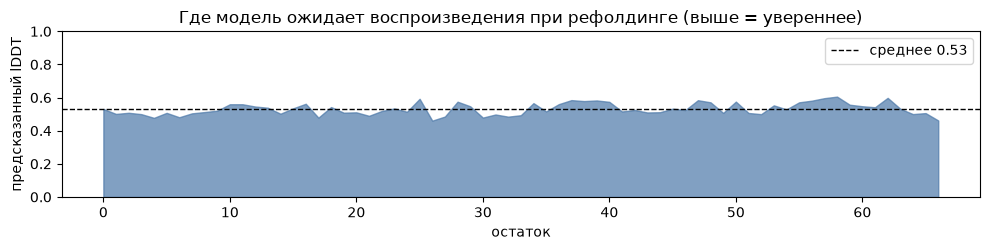

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 2.6))
ax.fill_between(range(len(lddt)), lddt, color="#4c78a8", alpha=0.7)
ax.axhline(lddt.mean(), color="black", ls="--", lw=1, label=f"среднее {lddt.mean():.2f}")
ax.set_xlabel("остаток")
ax.set_ylabel("предсказанный lDDT")
ax.set_title("Где модель ожидает воспроизведения при рефолдинге (выше = увереннее)")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

Профиль показывает, какие участки модель считает воспроизводимыми при рефолдинге.
Провалы — обычно петли и концы цепи.

Важная оговорка: **ранжировать структуры нужно головой `fold_logit`, а не средним lDDT.**
По-остаточный лосс работает как регуляризатор представления — он делает энкодер
чувствительнее к локальной геометрии, но прямая супервизия целевым скаляром
ранжирует лучше на всех генераторах (docs/05, раздел 3.7 и 5.6).

## 5. Все образцы в data/

In [9]:
import pandas as pd

rows = []
for path in sorted(glob.glob("data/*.pdb")):
    c = torch.from_numpy(center_coords(parse_pdb_to_backbone(path))).unsqueeze(0).to(device)
    m = torch.ones((1, c.shape[1]), dtype=torch.bool, device=device)
    with torch.no_grad(), _autocast_ctx(device):
        p = model(c, m)
        clashes = int((model.frontend.geometry(c, m)["clash_count"].sum() / 2).item())
    s = max(0.0, torch.expm1(p["fold_logit"].float()).item())
    rows.append({
        "структура": os.path.basename(path),
        "L": c.shape[1],
        "pred scRMSD, Å": round(s, 2),
        "дизайнуем": "да" if s < 2.0 else "нет",
        "mean lDDT": round(torch.sigmoid(p["lddt_logit"].float())[0].mean().item(), 3),
        "клэши": clashes,
        "failure mode": FAILURE_MODE_NAMES[int(p["failure_mode"].argmax())],
    })

pd.DataFrame(rows).sort_values("pred scRMSD, Å")

,структура,L,"pred scRMSD, Å",дизайнуем,mean lDDT,клэши,failure mode
3,my_protein_0.pdb,234,0.97,да,0.693,1,hard
7,my_protein_4.pdb,216,1.05,да,0.800,0,hard
5,my_protein_2.pdb,242,1.14,да,0.796,2,hard
8,my_protein_5.pdb,216,1.14,да,0.789,0,hard
6,my_protein_3.pdb,202,1.63,да,0.718,0,hard
4,my_protein_1.pdb,204,1.74,да,0.722,1,hard
2,3MYC.pdb,64,5.13,нет,0.618,0,hard
1,2RJW.pdb,134,5.17,нет,0.644,1,hard
0,2RJV.pdb,67,5.94,нет,0.531,1,hard


### Почему нативы выглядят «недизайнируемыми»

В таблице нативные структуры из PDB (`2RJV`, `2RJW`, `3MYC`) получают 5–6 Å, а выходы
генератора — 1–1.7 Å. Это не ошибка чтения и не поломка: это **известная слепая зона**
ранжирующей модели.

Голова дообучалась только на выходах генераторов, где нативов нет вообще, поэтому
абсолютная шкала на них не определена — модель экстраполирует за пределы обучающего
распределения. Внутри своего домена (сравнение кандидатов одного генератора под один
мотив) ранжирование корректно, и именно так фильтр и применяется.

Абсолютную шкалу чинит native-якорь (`soft_model_mt.pth`), но ценой ранжирования на
новых генераторах — измерено падение ODesign 2.82× → 1.42×. Поэтому роли разделены:
вердикт и ранжирование даёт чистая soft/joint-модель, похожесть на натив —
диагностическая, и в вердикте она не участвует (docs/05, раздел 5.4).

Столбец `failure mode` — наследие обучения на синтетических декоях; на генеративных
остовах он почти всегда `hard` и информативен слабо. Он остаётся диагностическим.

Тот же пайплайн в батчевом виде использует `filter_designability.py` — фильтр с гейтами
PASS/FAIL. Замеры скорости — в тетради `03-benchmark.ipynb`.

## 6. Диагностика: какие признаки портят предсказание

Integrated Gradients по 31 узловому признаку. Атрибуция считается для
**предсказанного scRMSD**, поэтому положительный вклад = признак ухудшает оценку
(повышает предсказанный scRMSD), отрицательный = улучшает.

In [10]:
import numpy as np

# Порядок ровно соответствует конкатенации в BiophysicalFrontend.forward:
# geometry.pack_for_mlp() (10) ++ designability.pack_for_mlp() (21) = 31
FEATURE_NAMES = [
    "φ sin", "φ cos", "ψ sin", "ψ cos", "ω sin", "ω cos",
    "Cα-Cα дист.", "Рамачандран-аутлайер", "H-связи", "стерич. конфликты",
    "упаковка r≤6Å", "упаковка r≤8Å", "упаковка r≤10Å",
    "экспонированность (burial)", "локальный изгиб",
] + [f"PCA-фрагмент {i}" for i in range(16)]
assert len(FEATURE_NAMES) == 31

# Эталон IG — не структура целиком, а её УСРЕДНЁННЫЙ по остаткам профиль признаков:
# синтетический «средний остаток», от которого отсчитывается вклад каждого признака.
BASELINE_PDB = "data/3MYC.pdb"
with torch.no_grad():
    bc = torch.from_numpy(center_coords(parse_pdb_to_backbone(BASELINE_PDB))).unsqueeze(0).to(device)
    bm = torch.ones((1, bc.shape[1]), dtype=torch.bool, device=device)
    baseline_feats = model.frontend(bc, bm)["node_feats"].mean(dim=1, keepdim=True)
print(f"Эталон: усреднённый профиль признаков {BASELINE_PDB} → {tuple(baseline_feats.shape)}")

Эталон: усреднённый профиль признаков data/3MYC.pdb → (1, 1, 31)


In [11]:
def integrated_gradients(pdb_path: str, baseline: torch.Tensor, steps: int = 64) -> dict:
    """IG по узловым признакам для предсказанного scRMSD (в log1p-шкале).

    Возвращает атрибуции [L, 31]; их сумма должна совпасть с разностью
    предсказаний белка и эталона (аксиома полноты).
    """
    model.eval()
    coords_np = center_coords(parse_pdb_to_backbone(pdb_path))
    c = torch.from_numpy(coords_np).unsqueeze(0).to(device)
    m = torch.ones((1, c.shape[1]), dtype=torch.bool, device=device)

    with torch.no_grad():
        feats = model.frontend(c, m)
    x = feats["node_feats"]
    base = baseline.expand_as(x)

    def head(node_feats):
        f = dict(feats)
        f["node_feats"] = node_feats
        repr_, _, _ = model.encode_features(f)
        return model.predict_from_repr(repr_)["fold_logit"].float()

    with torch.no_grad():
        y_in = head(x).item()
        y_base = head(base).item()

    total = torch.zeros_like(x)
    for s in range(steps):
        alpha = (s + 0.5) / steps
        point = (base + alpha * (x - base)).detach().requires_grad_(True)
        f = dict(feats)
        f["node_feats"] = point
        repr_, _, _ = model.encode_features(f)
        out = model.predict_from_repr(repr_)["fold_logit"].float().sum()
        (grad,) = torch.autograd.grad(out, point)
        total += grad
    attributions = (x - base) * total / steps

    return {
        "path": pdb_path, "length": x.shape[1],
        "attributions": attributions[0].detach().cpu(),
        "y_input": y_in, "y_baseline": y_base,
        "scrmsd_input": float(np.expm1(y_in)), "scrmsd_baseline": float(np.expm1(y_base)),
    }

In [12]:
res = integrated_gradients("data/2RJW.pdb", baseline_feats)

print(f"{res['path']}  (L={res['length']})")
print(f"  предсказание белка   = {res['scrmsd_input']:.2f} Å  (log1p {res['y_input']:+.3f})")
print(f"  предсказание эталона = {res['scrmsd_baseline']:.2f} Å  (log1p {res['y_baseline']:+.3f})")
print(f"  сумма атрибуций      = {res['attributions'].sum():+.3f}   "
      f"(аксиома полноты: должна ≈ {res['y_input'] - res['y_baseline']:+.3f})")

per_feature = res["attributions"].sum(dim=0).numpy()
order = per_feature.argsort()[::-1]   # первыми — сильнее всего ухудшающие

print("\nПризнаки, сильнее всего ухудшающие предсказание относительно эталона:")
for i in order[:6]:
    print(f"  {FEATURE_NAMES[i]:28} {per_feature[i]:+.3f}")

/home/pc/PycharmProjects/BbValidator/.venv/lib/python3.13/site-packages/torch/autograd/graph.py:869: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:335.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


data/2RJW.pdb  (L=134)
  предсказание белка   = 5.19 Å  (log1p +1.823)
  предсказание эталона = -0.01 Å  (log1p -0.014)
  сумма атрибуций      = +1.690   (аксиома полноты: должна ≈ +1.836)

Признаки, сильнее всего ухудшающие предсказание относительно эталона:
  PCA-фрагмент 0               +0.905
  PCA-фрагмент 2               +0.620
  PCA-фрагмент 6               +0.598
  PCA-фрагмент 5               +0.466
  PCA-фрагмент 8               +0.441
  PCA-фрагмент 13              +0.356


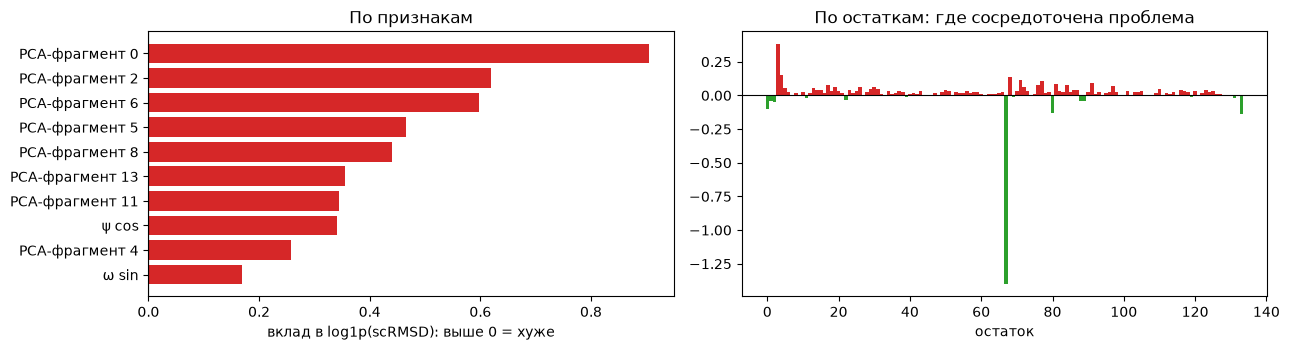

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))

top = order[:10][::-1]
axes[0].barh([FEATURE_NAMES[i] for i in top], [per_feature[i] for i in top],
             color=["#d62728" if per_feature[i] > 0 else "#2ca02c" for i in top])
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("вклад в log1p(scRMSD): выше 0 = хуже")
axes[0].set_title("По признакам")

per_res = res["attributions"].sum(dim=-1).numpy()
axes[1].bar(range(len(per_res)), per_res, width=1.0,
            color=["#d62728" if v > 0 else "#2ca02c" for v in per_res])
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("остаток")
axes[1].set_title("По остаткам: где сосредоточена проблема")

plt.tight_layout()
plt.show()

Левый график отвечает на «**что** не так», правый — «**где** не так».

Оговорка о пределах интерпретации: атрибуция объясняет решение модели, а не физику.
Часть входных признаков заведомо слабая — H-связи считаются по расстоянию O···N без
углового члена и нулевые у 46–52% остатков, счётчик клэшей нулевой почти везде на
генеративных остовах. Высокий вклад такого признака говорит о модели, а не о структуре.

### Диагностика любого белка одной командой

=== my_protein_2.pdb  (L=242) ===
предсказанный scRMSD = 1.15 Å (эталон 0.53 Å) → дизайнуем
сумма атрибуций = +0.348 (≈ разность +0.340)

сильнее всего ухудшают:
  PCA-фрагмент 13              +0.850
  PCA-фрагмент 10              +0.724
  PCA-фрагмент 6               +0.612
  PCA-фрагмент 4               +0.522
  PCA-фрагмент 11              +0.492
  φ cos                        +0.460
  Cα-Cα дист.                  +0.229
  ψ cos                        +0.219


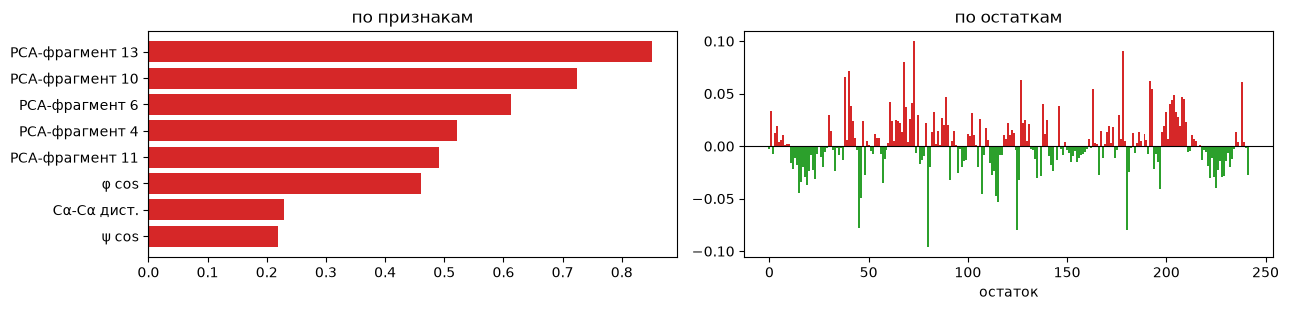

In [14]:
def explain_protein(pdb_path: str, top_k: int = 8, steps: int = 32) -> dict:
    """Отчёт и два графика для произвольного PDB: что и где ухудшает предсказание."""
    r = integrated_gradients(pdb_path, baseline_feats, steps=steps)
    pf = r["attributions"].sum(dim=0).numpy()
    pr = r["attributions"].sum(dim=-1).numpy()

    print(f"=== {os.path.basename(pdb_path)}  (L={r['length']}) ===")
    print(f"предсказанный scRMSD = {r['scrmsd_input']:.2f} Å "
          f"(эталон {r['scrmsd_baseline']:.2f} Å) → "
          f"{'дизайнуем' if r['scrmsd_input'] < 2.0 else 'НЕ дизайнуем'}")
    print(f"сумма атрибуций = {r['attributions'].sum():+.3f} "
          f"(≈ разность {r['y_input'] - r['y_baseline']:+.3f})")

    worst = pf.argsort()[::-1][:top_k]
    print()
    print("сильнее всего ухудшают:")
    for i in worst:
        print(f"  {FEATURE_NAMES[i]:28} {pf[i]:+.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(13, 3.2))
    sel = worst[::-1]
    axes[0].barh([FEATURE_NAMES[i] for i in sel], [pf[i] for i in sel],
                 color=["#d62728" if pf[i] > 0 else "#2ca02c" for i in sel])
    axes[0].axvline(0, color="black", lw=0.8)
    axes[0].set_title("по признакам")
    axes[1].bar(range(len(pr)), pr, width=1.0,
                color=["#d62728" if v > 0 else "#2ca02c" for v in pr])
    axes[1].axhline(0, color="black", lw=0.8)
    axes[1].set_xlabel("остаток")
    axes[1].set_title("по остаткам")
    plt.tight_layout()
    plt.show()
    return r


_ = explain_protein("data/my_protein_2.pdb")